# Olist E-Commerce Analysis - Delivery Experience

This is the main analysis I wanted to do. Olist promises customers a delivery date when they place an order - I want to see how often they actually hit it, which states have the worst track record, and whether being late actually tanks review scores.

So: overall on-time vs late split first, then breaking it down by state, then a t-test on review scores to see if the difference is statistically real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# setting a consistent style for all charts
plt.style.use('seaborn-v0_8-whitegrid')

Matplotlib is building the font cache; this may take a moment.


In [2]:
BASE_DIR = os.path.abspath("..")
PROCESSED_PATH = os.path.join(BASE_DIR, "data", "processed")
CHARTS_PATH = os.path.join(BASE_DIR, "outputs", "charts")

# loading the cleaned master table
master = pd.read_csv(os.path.join(PROCESSED_PATH, "master_clean.csv"))

# re-parsing dates - they come back as strings from CSV
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col])

print(f"loaded master table: {master.shape}")

loaded master table: (110197, 25)


## Part 1 - computing delivery time

In [3]:
# how many days did each order actually take?
master['actual_delivery_days'] = (
    master['order_delivered_customer_date'] - master['order_purchase_timestamp']
).dt.days

# how many days did olist promise it would take?
master['estimated_delivery_days'] = (
    master['order_estimated_delivery_date'] - master['order_purchase_timestamp']
).dt.days

# positive = delivered late, negative = delivered early
master['delivery_delta'] = master['actual_delivery_days'] - master['estimated_delivery_days']

print("delivery time columns added")
print(master[['actual_delivery_days', 'estimated_delivery_days', 'delivery_delta']].describe())

delivery time columns added
       actual_delivery_days  estimated_delivery_days  delivery_delta
count         110189.000000            110197.000000   110189.000000
mean              12.007342                23.439631      -11.432285
std                9.451153                 8.822024       10.168323
min                0.000000                 2.000000     -146.000000
25%                6.000000                18.000000      -17.000000
50%               10.000000                23.000000      -12.000000
75%               15.000000                28.000000       -7.000000
max              209.000000               155.000000      189.000000


In [4]:
# classifying each order
def classify_delivery(delta):
    if delta < 0:
        return 'early'
    elif delta == 0:
        return 'on-time'
    else:
        return 'late'

master['delivery_status'] = master['delivery_delta'].apply(classify_delivery)

# what's the breakdown?
status_counts = master['delivery_status'].value_counts()
status_pct = master['delivery_status'].value_counts(normalize=True) * 100

print("delivery status breakdown:")
for status in status_counts.index:
    print(f"  {status}: {status_counts[status]:,} orders ({status_pct[status]:.1f}%)")

delivery status breakdown:
  early: 100,525 orders (91.2%)
  late: 8,154 orders (7.4%)
  on-time: 1,518 orders (1.4%)


I noticed that a lot more orders arrive early than I expected. That's probably because Olist builds a generous buffer into the estimated date. Still, there's a non-trivial chunk of late orders that I'll dig into next.

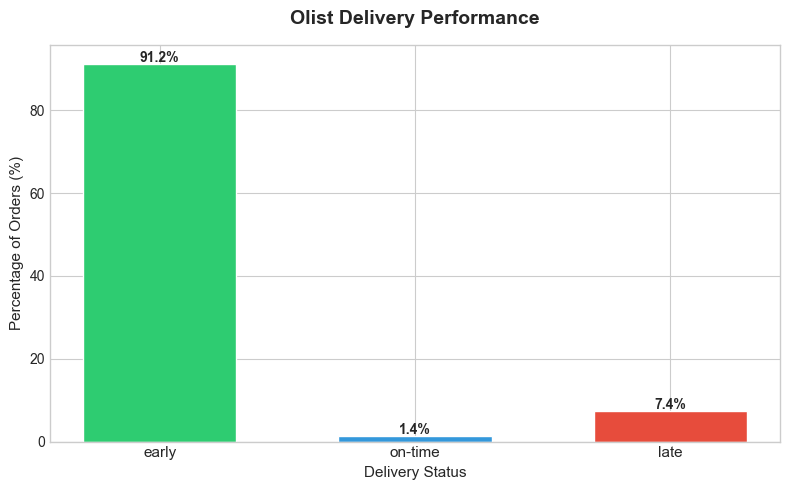

chart saved


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'early': '#2ecc71', 'on-time': '#3498db', 'late': '#e74c3c'}

# sorting so it shows early, on-time, late in that order
ordered = ['early', 'on-time', 'late']
ordered_pct = [status_pct.get(s, 0) for s in ordered]
ordered_counts = [status_counts.get(s, 0) for s in ordered]
bar_colors = [colors[s] for s in ordered]

ax.bar(ordered, ordered_pct, color=bar_colors, edgecolor='white', width=0.6)

ax.set_title('Olist Delivery Performance', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Delivery Status', fontsize=11)
ax.set_ylabel('Percentage of Orders (%)', fontsize=11)
ax.tick_params(axis='x', labelsize=11)

# adding percentage labels on top of bars
for i, (count, pct) in enumerate(zip(ordered_counts, ordered_pct)):
    ax.text(i, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, '01_delivery_status.png'), dpi=150, bbox_inches='tight')
plt.show()
print("chart saved")

## Part 2 - which states have the worst delivery performance?

In [6]:
# grouping by customer state to see where late deliveries are concentrated
state_delivery = master.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x == 'late').sum()),
    avg_delivery_days=('actual_delivery_days', 'mean')
).reset_index()

state_delivery['late_rate'] = (state_delivery['late_orders'] / state_delivery['total_orders']) * 100
state_delivery = state_delivery.sort_values('late_rate', ascending=False)

print("top 10 states by late delivery rate:")
print(state_delivery.head(10)[['customer_state', 'total_orders', 'late_rate', 'avg_delivery_days']].to_string(index=False))

top 10 states by late delivery rate:
customer_state  total_orders  late_rate  avg_delivery_days
            AL           427  23.185012          23.992974
            MA           800  19.625000          21.203750
            SE           375  16.266667          20.978667
            CE          1426  14.796634          20.537167
            PI           523  14.722753          18.931166
            BA          3683  12.897095          18.774640
            RJ         14143  12.416036          14.688821
            PA          1054  12.144213          23.301708
            TO           310  11.935484          17.003226
            ES          2225  11.775281          15.192809


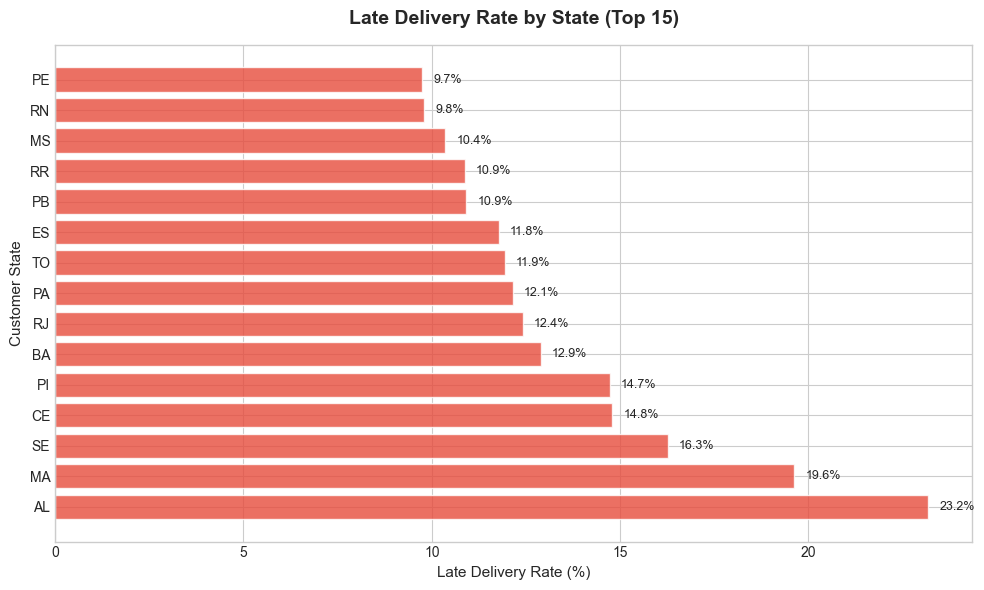

chart saved


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

top_states = state_delivery.head(15)
bars = ax.barh(
    top_states['customer_state'],
    top_states['late_rate'],
    color='#e74c3c', alpha=0.8, edgecolor='white'
)

ax.set_title('Late Delivery Rate by State (Top 15)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Late Delivery Rate (%)', fontsize=11)
ax.set_ylabel('Customer State', fontsize=11)

# adding value labels
for bar, val in zip(bars, top_states['late_rate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, '02_late_delivery_by_state.png'), dpi=150, bbox_inches='tight')
plt.show()
print("chart saved")

## Part 3 - does being late actually affect review scores?

In [8]:
# dropping nulls here - review_score has some missing values
late_reviews   = master[master['delivery_status'] == 'late']['review_score'].dropna()
ontime_reviews = master[master['delivery_status'] != 'late']['review_score'].dropna()

print(f"late orders    - avg review score: {late_reviews.mean():.2f}   (n={len(late_reviews):,})")
print(f"on-time/early  - avg review score: {ontime_reviews.mean():.2f}  (n={len(ontime_reviews):,})")

late orders    - avg review score: 2.45   (n=7,965)
on-time/early  - avg review score: 4.21  (n=101,405)


In [9]:
# running a t-test to check if the difference is statistically significant
# null hypothesis: late and on-time deliveries have the same average review score
t_stat, p_value = stats.ttest_ind(late_reviews, ontime_reviews)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")

if p_value < 0.05:
    print("\nresult: the difference IS statistically significant (p < 0.05)")
    print("late deliveries genuinely lead to lower review scores - not just random noise")
    # ok so this confirms it - being late really does hurt your score
else:
    print("\nresult: the difference is NOT statistically significant")

t-statistic: -119.5742
p-value:     0.000000

result: the difference IS statistically significant (p < 0.05)
late deliveries genuinely lead to lower review scores - not just random noise


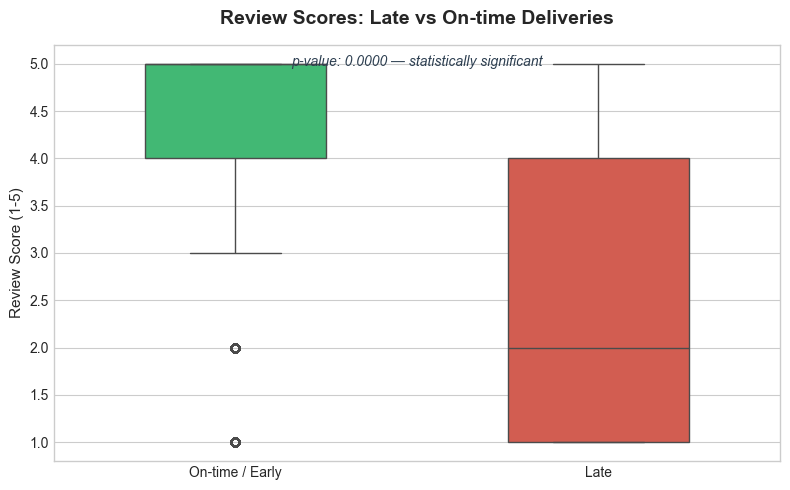

chart saved


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = master[['delivery_status', 'review_score']].dropna().copy()
plot_data['group'] = plot_data['delivery_status'].apply(
    lambda x: 'Late' if x == 'late' else 'On-time / Early'
)

sns.boxplot(
    data=plot_data, x='group', y='review_score',
    palette={'Late': '#e74c3c', 'On-time / Early': '#2ecc71'},
    ax=ax, width=0.5
)

ax.set_title('Review Scores: Late vs On-time Deliveries', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Review Score (1-5)', fontsize=11)

ax.text(
    0.5, 0.95,
    f'p-value: {p_value:.4f} - statistically significant',
    transform=ax.transAxes, ha='center', fontsize=10,
    color='#2c3e50', style='italic'
)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, '03_review_score_vs_delivery.png'), dpi=150, bbox_inches='tight')
plt.show()
print("chart saved")

## what I found

7.4% late sounds manageable, but the context makes it interesting - 91% of orders arrive *early* because Olist builds a huge buffer into their estimates. So the orders that do slip through as late are genuinely failing, not just barely missing.

The late rate isn't spread evenly across states. Alagoas is at 23%, Maranhão at 19.6%. Both are in the northeast and far from the main logistics hubs down south.

The review score gap is real: 2.45 for late orders vs 4.21 for on-time/early, and the t-test p-value is basically zero. Being late genuinely hurts your rating.

A few things I'd dig into next: is the late delivery problem coming from slow shipping out of the warehouse, or is it last-mile delivery in those specific regions? Those are different problems. And with a buffer that generous, tightening estimates for high-risk states probably wouldn't make things worse.